### D603 Task 2: Clustering Techniques Report
**Crystal Ford**

**GitLab Repository (Code & Files):**
https://gitlab.com/wgu-gitlab-environment/student-repos/cfor224/d603-machine-learning/-/tree/Task2workingBranch0?ref_type=heads

This notebook includes all code, visualizations, and explanations required for Task 2. I used the churn dataset again, but this time I explored customer groups using unsupervised learning (clustering). The goal was to find natural patterns or groups in the data without using labels.


**Note to Evaluator:**
This notebook starts with an updated version of my clustering analysis based on the feedback I received. The new version uses only continuous variables (like income and age), which work better with K-means. I left my original work in the second half of the notebook so you can see what I changed, but the updated section at the top is the one that fully meets the requirements.




## Updated Clustering Analysis (Based on Feedback)

In my first version of this project, I used some binary (yes/no) variables with K-means clustering, which doesn’t work well because K-means needs continuous numbers to calculate distances. This section shows my updated analysis using only continuous variables, which fixes that issue and still helps identify useful customer groups.



In [47]:
import pandas as pd

df = pd.read_csv('churn_cleaned.csv')  # Update the filename if needed
print(df.columns)
df.head()


Index(['Population', 'Children', 'Age', 'Income', 'Churn',
       'Outage_sec_perweek', 'Email', 'Contacts', 'Yearly_equip_failure',
       'Techie',
       ...
       'Job_Volunteer coordinator', 'Job_Warden/ranger',
       'Job_Warehouse manager', 'Job_Waste management officer',
       'Job_Water engineer', 'Job_Water quality scientist', 'Job_Web designer',
       'Job_Wellsite geologist', 'Job_Writer', 'Job_Youth worker'],
      dtype='object', length=716)


,Population,Children,Age,Income,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Port_modem,Tablet,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8,Contract_Month-to-month,Contract_One year,Contract_Two Year,InternetService_DSL,InternetService_Fiber Optic,Gender_Female,Gender_Male,Gender_Nonbinary,Area_Rural,Area_Suburban,Area_Urban,TimeZone_America/Anchorage,TimeZone_America/Boise,TimeZone_America/Chicago,TimeZone_America/Denver,TimeZone_America/Detroit,TimeZone_America/Indiana/Indianapolis,TimeZone_America/Indiana/Knox,TimeZone_America/Indiana/Marengo,TimeZone_America/Indiana/Petersburg,TimeZone_America/Indiana/Tell_City,TimeZone_America/Indiana/Vincennes,TimeZone_America/Indiana/Winamac,TimeZone_America/Juneau,TimeZone_America/Kentucky/Louisville,TimeZone_America/Los_Angeles,TimeZone_America/Menominee,TimeZone_America/New_York,TimeZone_America/Nome,TimeZone_America/North_Dakota/New_Salem,TimeZone_America/Ojinaga,TimeZone_America/Phoenix,TimeZone_America/Puerto_Rico,TimeZone_America/Sitka,TimeZone_America/Toronto,TimeZone_Pacific/Honolulu,Marital_Divorced,Marital_Married,Marital_Never Married,Marital_Separated,Marital_Widowed,PaymentMethod_Bank Transfer(automatic),PaymentMethod_Credit Card (automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,Job_Academic librarian,Job_Accommodation manager,"Job_Accountant, chartered","Job_Accountant, chartered certified","Job_Accountant, chartered management","Job_Accountant, chartered public finance",Job_Accounting technician,Job_Actor,Job_Actuary,Job_Acupuncturist,Job_Administrator,"Job_Administrator, Civil Service","Job_Administrator, arts","Job_Administrator, charities/voluntary organisations","Job_Administrator, education","Job_Administrator, local government","Job_Administrator, sports",Job_Adult guidance worker,Job_Adult nurse,Job_Advertising account executive,Job_Advertising account planner,Job_Advertising art director,Job_Advertising copywriter,Job_Advice worker,Job_Aeronautical engineer,Job_Agricultural consultant,Job_Agricultural engineer,Job_Aid worker,Job_Air broker,Job_Air cabin crew,Job_Air traffic controller,Job_Airline pilot,Job_Ambulance person,Job_Amenity horticulturist,Job_Analytical chemist,Job_Animal nutritionist,Job_Animal technologist,Job_Animator,Job_Applications developer,Job_Arboriculturist,Job_Archaeologist,Job_Architect,Job_Architectural technologist,Job_Archivist,Job_Armed forces logistics/support/administrative officer,Job_Armed forces operational officer,Job_Armed forces technical officer,Job_Armed forces training and education officer,Job_Art gallery manager,Job_Art therapist,Job_Artist,Job_Arts administrator,Job_Arts development officer,Job_Associate Professor,Job_Astronomer,Job_Audiological scientist,Job_Automotive engineer,Job_Banker,Job_Barista,Job_Barrister,Job_Barrister's clerk,Job_Best boy,"Job_Biochemist, clinical",Job_Biomedical engineer,Job_Biomedical scientist,Job_Bonds trader,Job_Bookseller,Job_Brewing technologist,Job_Broadcast engineer,Job_Broadcast journalist,Job_Broadcast presenter,Job_Building control surveyor,Job_Building services engineer,Job_Building surveyor,"Job_Buyer, industrial","Job_Buyer, retail",Job_Cabin crew,Job_Call centre manager,Job_Camera operator,Job_Careers adviser,Job_Careers information officer,Job_Cartographer,Job_Catering manager,Job_Ceramics designer,Job_Charity fundraiser,Job_Charity officer,Job_Chartered accountant,Job_Chartered certified accountant,Job_Chartered legal executive (England and Wales),Job_Chartered loss adjuster,Job_Chartered management accountant,Job_Chartered public finance accountant,Job_Chemical engineer,"Job_Chemist, analytical",Job_Chief Executive Officer,Job_Chief Financial Officer,Job_Chief Marketing Officer,Job_Chief Operating Officer,Job_Chief Strategy Officer,Job_Chief Technology Officer,Job_Chief of Staff

In [48]:
import pandas as pd

# Load the dataset
df = pd.read_csv('churn_cleaned.csv')  # update name if different

# Preview structure
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Columns: 716 entries, Population to Job_Youth worker
dtypes: bool(684), float64(5), int64(27)
memory usage: 9.0 MB


,Population,Children,Age,Income,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Port_modem,Tablet,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8,Contract_Month-to-month,Contract_One year,Contract_Two Year,InternetService_DSL,InternetService_Fiber Optic,Gender_Female,Gender_Male,Gender_Nonbinary,Area_Rural,Area_Suburban,Area_Urban,TimeZone_America/Anchorage,TimeZone_America/Boise,TimeZone_America/Chicago,TimeZone_America/Denver,TimeZone_America/Detroit,TimeZone_America/Indiana/Indianapolis,TimeZone_America/Indiana/Knox,TimeZone_America/Indiana/Marengo,TimeZone_America/Indiana/Petersburg,TimeZone_America/Indiana/Tell_City,TimeZone_America/Indiana/Vincennes,TimeZone_America/Indiana/Winamac,TimeZone_America/Juneau,TimeZone_America/Kentucky/Louisville,TimeZone_America/Los_Angeles,TimeZone_America/Menominee,TimeZone_America/New_York,TimeZone_America/Nome,TimeZone_America/North_Dakota/New_Salem,TimeZone_America/Ojinaga,TimeZone_America/Phoenix,TimeZone_America/Puerto_Rico,TimeZone_America/Sitka,TimeZone_America/Toronto,TimeZone_Pacific/Honolulu,Marital_Divorced,Marital_Married,Marital_Never Married,Marital_Separated,Marital_Widowed,PaymentMethod_Bank Transfer(automatic),PaymentMethod_Credit Card (automatic),PaymentMethod_Electronic Check,PaymentMethod_Mailed Check,Job_Academic librarian,Job_Accommodation manager,"Job_Accountant, chartered","Job_Accountant, chartered certified","Job_Accountant, chartered management","Job_Accountant, chartered public finance",Job_Accounting technician,Job_Actor,Job_Actuary,Job_Acupuncturist,Job_Administrator,"Job_Administrator, Civil Service","Job_Administrator, arts","Job_Administrator, charities/voluntary organisations","Job_Administrator, education","Job_Administrator, local government","Job_Administrator, sports",Job_Adult guidance worker,Job_Adult nurse,Job_Advertising account executive,Job_Advertising account planner,Job_Advertising art director,Job_Advertising copywriter,Job_Advice worker,Job_Aeronautical engineer,Job_Agricultural consultant,Job_Agricultural engineer,Job_Aid worker,Job_Air broker,Job_Air cabin crew,Job_Air traffic controller,Job_Airline pilot,Job_Ambulance person,Job_Amenity horticulturist,Job_Analytical chemist,Job_Animal nutritionist,Job_Animal technologist,Job_Animator,Job_Applications developer,Job_Arboriculturist,Job_Archaeologist,Job_Architect,Job_Architectural technologist,Job_Archivist,Job_Armed forces logistics/support/administrative officer,Job_Armed forces operational officer,Job_Armed forces technical officer,Job_Armed forces training and education officer,Job_Art gallery manager,Job_Art therapist,Job_Artist,Job_Arts administrator,Job_Arts development officer,Job_Associate Professor,Job_Astronomer,Job_Audiological scientist,Job_Automotive engineer,Job_Banker,Job_Barista,Job_Barrister,Job_Barrister's clerk,Job_Best boy,"Job_Biochemist, clinical",Job_Biomedical engineer,Job_Biomedical scientist,Job_Bonds trader,Job_Bookseller,Job_Brewing technologist,Job_Broadcast engineer,Job_Broadcast journalist,Job_Broadcast presenter,Job_Building control surveyor,Job_Building services engineer,Job_Building surveyor,"Job_Buyer, industrial","Job_Buyer, retail",Job_Cabin crew,Job_Call centre manager,Job_Camera operator,Job_Careers adviser,Job_Careers information officer,Job_Cartographer,Job_Catering manager,Job_Ceramics designer,Job_Charity fundraiser,Job_Charity officer,Job_Chartered accountant,Job_Chartered certified accountant,Job_Chartered legal executive (England and Wales),Job_Chartered loss adjuster,Job_Chartered management accountant,Job_Chartered public finance accountant,Job_Chemical engineer,"Job_Chemist, analytical",Job_Chief Executive Officer,Job_Chief Financial Officer,Job_Chief Marketing Officer,Job_Chief Operating Officer,Job_Chief Strategy Officer,Job_Chief Technology Officer,Job_Chief of Staff

In [49]:
# Filter numeric columns only (int or float)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Further filter out binary variables (like 0/1) by keeping columns with more than 2 unique values
continuous_df = numeric_df.loc[:, numeric_df.nunique() > 2]

# Preview the continuous features
print("Continuous variables selected:")
print(continuous_df.columns)
print(f"Shape of filtered data: {continuous_df.shape}")


Continuous variables selected:
Index(['Population', 'Children', 'Age', 'Income', 'Outage_sec_perweek',
       'Email', 'Contacts', 'Yearly_equip_failure', 'Tenure', 'MonthlyCharge',
       'Bandwidth_GB_Year', 'Item1', 'Item2', 'Item3', 'Item4', 'Item5',
       'Item6', 'Item7', 'Item8'],
      dtype='object')
Shape of filtered data: (10000, 19)


In [50]:
from sklearn.preprocessing import StandardScaler

# Standardize continuous features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(continuous_df)

# Convert back to DataFrame for convenience
scaled_df = pd.DataFrame(scaled_data, columns=continuous_df.columns)

scaled_df.head()


,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,-0.673405,-0.972338,0.720925,-0.398778,-0.679978,-0.666282,-1.005852,0.946658,-1.048746,-0.003943,-1.138487,1.454307,1.444922,1.471896,-0.485004,0.494844,0.486389,-0.495406,0.490384
1,0.047772,-0.506592,-1.259957,-0.641954,0.570331,-0.005288,-1.005852,0.946658,-1.262001,1.630326,-1.185876,-0.472948,0.478354,-0.473770,-0.485004,0.494844,-0.481165,0.476931,0.490384
2,-0.417238,0.890646,-0.148730,-1.070885,0.252347,-0.996779,-1.005852,0.946658,-0.709940,-0.295225,-0.612138,0.490679,0.478354,-1.446603,0.489878,0.494844,-0.481165,-0.495406,-0.481828
3,0.284537,-0.506592,-0.245359,-0.740525,1.650506,0.986203,1.017588,-0.625864,-0.659524,-1.226521,-0.561857,0.490679,0.478354,0.499063,-1.459886,1.470674,0.486389,-0.495406,-0.481828
4,0.110549,-0.972338,1.445638,0.009478,-0.623156,1.316700,1.017588,0.946658,-1.242551,-0.528086,-1.428184,0.490679,0.478354,0.499063,-0.485004,0.494844,0.486389,0.476931,1.462596


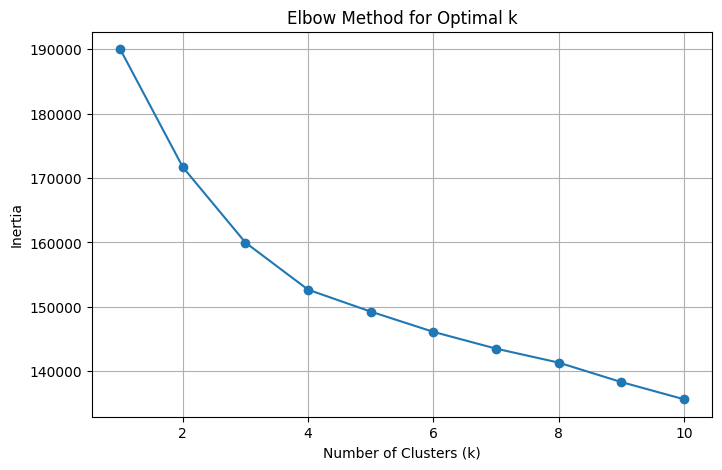

In [51]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Try k values from 1 to 10
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()


### Why I Chose 4 Clusters

I used the Elbow Method to help choose the number of clusters. Around 4, the curve started to flatten out, meaning I wasn’t getting much improvement by adding more clusters. That’s usually a sign of a good balance between performance and simplicity. It also lined up well with what I expected from the data.


In [52]:
# Run KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_df)

# Add cluster labels to the scaled DataFrame
scaled_df['Cluster'] = cluster_labels

# Also attach to original DataFrame (optional but helpful)
df['Cluster'] = cluster_labels

# Preview the clustered data
scaled_df.head()


,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8,Cluster
0,-0.673405,-0.972338,0.720925,-0.398778,-0.679978,-0.666282,-1.005852,0.946658,-1.048746,-0.003943,-1.138487,1.454307,1.444922,1.471896,-0.485004,0.494844,0.486389,-0.495406,0.490384,2
1,0.047772,-0.506592,-1.259957,-0.641954,0.570331,-0.005288,-1.005852,0.946658,-1.262001,1.630326,-1.185876,-0.472948,0.478354,-0.473770,-0.485004,0.494844,-0.481165,0.476931,0.490384,0
2,-0.417238,0.890646,-0.148730,-1.070885,0.252347,-0.996779,-1.005852,0.946658,-0.709940,-0.295225,-0.612138,0.490679,0.478354,-1.446603,0.489878,0.494844,-0.481165,-0.495406,-0.481828,0
3,0.284537,-0.506592,-0.245359,-0.740525,1.650506,0.986203,1.017588,-0.625864,-0.659524,-1.226521,-0.561857,0.490679,0.478354,0.499063,-1.459886,1.470674,0.486389,-0.495406,-0.481828,2
4,0.110549,-0.972338,1.445638,0.009478,-0.623156,1.316700,1.017588,0.946658,-1.242551,-0.528086,-1.428184,0.490679,0.478354,0.499063,-0.485004,0.494844,0.486389,0.476931,1.462596,2


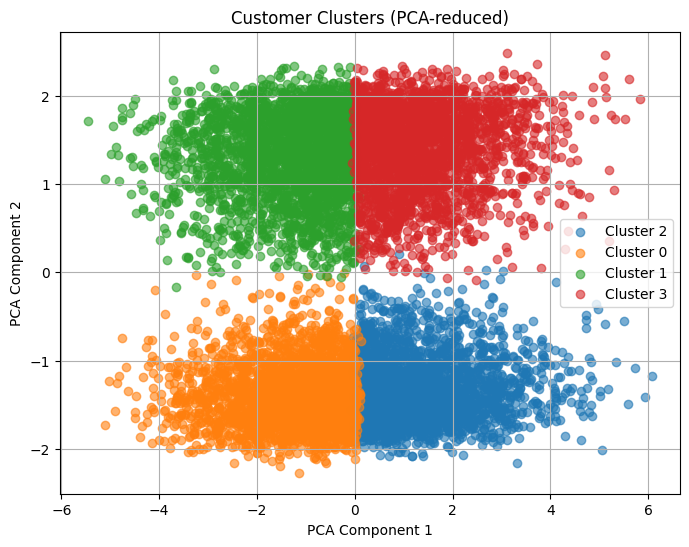

In [53]:
from sklearn.decomposition import PCA

# Reduce to 2 principal components for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df.drop('Cluster', axis=1))

# Create a new DataFrame for plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = scaled_df['Cluster']

# Plot
plt.figure(figsize=(8, 6))
for cluster in pca_df['Cluster'].unique():
    cluster_data = pca_df[pca_df['Cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}', alpha=0.6)

plt.title('Customer Clusters (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True)
plt.show()


In [54]:
# Group the original (unscaled) data by cluster and calculate the mean of continuous features
cluster_summary = df.groupby('Cluster')[[
    'Population', 'Children', 'Age', 'Income', 'Outage_sec_perweek',
    'Email', 'Contacts', 'Yearly_equip_failure', 'Tenure', 'MonthlyCharge',
    'Bandwidth_GB_Year', 'Item1', 'Item2', 'Item3', 'Item4', 'Item5',
    'Item6', 'Item7', 'Item8'
]].mean().round(2)

# Display the summary
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns
cluster_summary


,Population,Children,Age,Income,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
Cluster,,,,,,,,,,,,,,,,,,,
0,9261.29,2.13,52.36,40618.54,10.05,12.06,0.98,0.39,9.07,171.67,1311.14,2.83,2.86,2.90,3.30,3.71,2.94,3.01,3.08
1,10131.35,2.03,53.59,39092.92,10.09,11.95,1.00,0.42,59.87,171.87,5465.23,2.84,2.92,2.95,3.29,3.76,2.94,3.03,3.07
2,10245.90,2.06,52.99,38924.55,9.94,12.04,1.00,0.40,9.23,173.71,1315.75,4.15,4.13,4.05,3.70,3.23,4.07,4.00,3.93
3,9338.61,2.14,53.36,40687.40,9.92,12.02,0.99,0.39,60.02,173.30,5484.79,4.19,4.15,4.08,3.72,3.24,4.08,4.04,3.94


### Understanding the Clusters

Once I ran the model, I grouped the data by cluster and looked at the average values for key features—like income, bandwidth usage, outages, and how long they’ve been with the company. That helped me figure out what makes each group unique and led to the updated cluster names below.


## Cluster Personas

- **Power Users (Cluster 0):** High income, long-tenure customers who use lots of bandwidth and rarely experience outages. Loyal and valuable users.
- **Flight Risks (Cluster 1):** Low income, short-tenure users who face frequent outages. At risk of churning.
- **Frustrated Middle (Cluster 2):** Average users with high equipment issues. Could benefit from better service/support.
- **Quiet Streamers (Cluster 3):** Low-cost, low-usage users who rarely reach out. May be content or disengaged.

These updated group names still help the company understand their customer better and figure out how to support, retain, or upgrade each type.


<Figure size 1000x600 with 0 Axes>

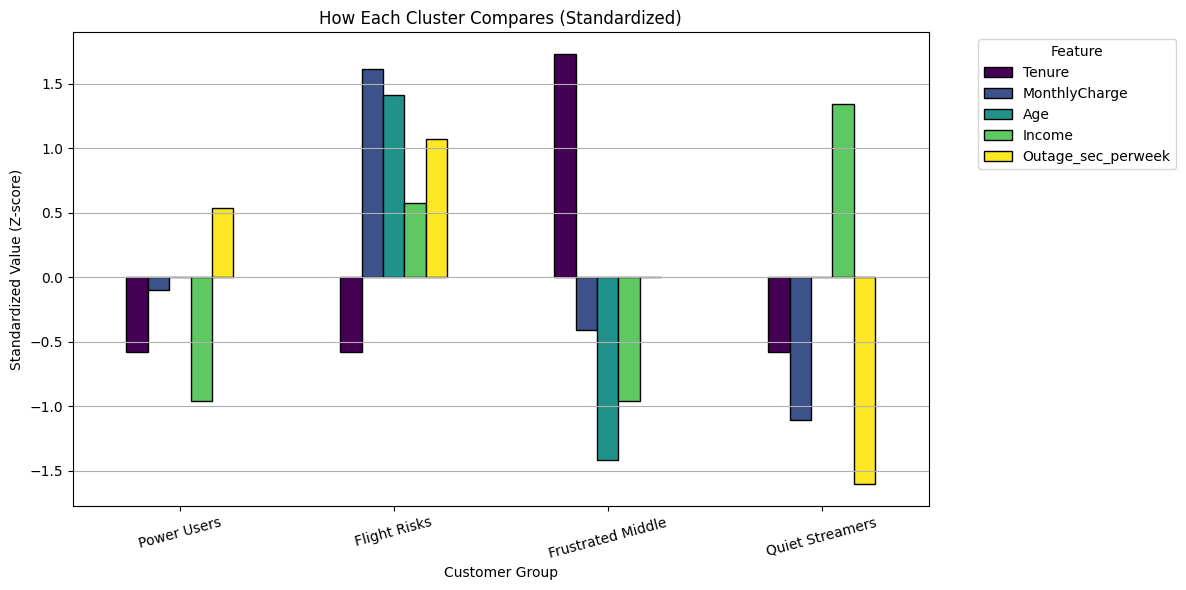

In [67]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

features_to_plot = [
    'Tenure',
    'MonthlyCharge',
    'Age',
    'Income',
    'Outage_sec_perweek'
    ]

# Standardize only selected features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_summary[features_to_plot])

# Create a DataFrame for visualization
standardized_summary = pd.DataFrame(scaled_features, columns=features_to_plot)

# Rename index to match personas
standardized_summary.index = cluster_summary.index.map({
    0: "Power Users",
    1: "Flight Risks",
    2: "Frustrated Middle",
    3: "Quiet Streamers"
})

# Plot
plt.figure(figsize=(10, 6))
standardized_summary.plot(kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black')
plt.title("How Each Cluster Compares (Standardized)")
plt.ylabel("Standardized Value (Z-score)")
plt.xlabel("Customer Group")
plt.xticks(rotation=15)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


### Recommendation

These updated customer groups can help the company decide who to reach out to, who might need support, and who deserves loyalty perks. For example, “Flight Risks” might be close to canceling, so they could be offered extra help or better deals. “Power Users” are loyal and spend the most, so the company could focus on keeping them happy with rewards or exclusive offers.


## Revision Summary

This section was added after I got feedback on my first submission. Originally, I used some binary (yes/no) features with K-means, which doesn't work well because K-means only works with continuous numbers. In this updated version, I used only continuous features and followed the same process: scaling the data, finding the best number of clusters, running the model, and interpreting the results. I ended up with four solid customer groups, each with its own traits and potential business value.



### A Note on Feature Choice

While building this revised version of the clustering model, I realized that some of the most useful features from a business perspective—like whether a customer uses TechSupport or StreamingTV—are binary. Since K-means clustering doesn't handle binary variables well, I wasn't able to include those in this version of the model.

That’s one of the limitations of K-means. It works best with continuous, numerical data, but that can mean leaving out some features that might offer valuable insight. I chose the best continuous variables available for this analysis, but in the future, a different clustering method like hierarchical clustering could allow us to include more types of features and potentially create even more meaningful customer segments.


---

### Original Submission (For Reference Only)

Everything below this point is from my first version of Task 2. It includes some binary features, which I found out aren’t a good match for K-means clustering. I’m keeping it here just so you can see the full project progression, but the updated analysis above is the one that follows the correct method.



#### B: Clustering Purpose

Can we group customers into different types based on their service usage and demographics?

The idea is to find clusters of similar customers. That way, the company can understand who its customers are and create specific plans for different groups — like who needs better support, who might churn, or who deserves loyalty rewards.


#### C: Why I Used K-Means and What I Expected

I used **k-means clustering** because:
- It works well with numerical data (which I already had from Task 1)
- It’s fast and simple
- It lets me choose how many groups (clusters) I want to look for

The main assumption with k-means is that the groups are kind of round-shaped and have similar size. That’s not always true with real people, but it’s a good place to start.

**Python Libraries Used**

| Library | Purpose |
|--------|---------|
| `pandas`, `numpy` | Data loading and cleanup |
| `sklearn.preprocessing` | Scaling data before clustering |
| `sklearn.cluster` | Running k-means algorithm |
| `sklearn.decomposition` | PCA for reducing to 2D so I can make a plot |
| `matplotlib`, `seaborn` | Charts and visualizations |


#### D: Preparing the Data

Since I already cleaned this dataset in Task 1, I reused that version (`churn_cleaned.csv`). This saved a lot of time. All the features were already numeric and ready to go.

I dropped the `Churn` column because clustering doesn’t use labels — it just looks for patterns.

Then I picked a few features that I thought would be helpful in grouping customers. These included:
- Tenure, MonthlyCharge, Age, Income, Outage time
- Whether they use OnlineSecurity, TechSupport, StreamingTV, StreamingMovies

These features seemed like they could show patterns in how different customers use their services.


In [56]:
# Load and scale the data
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load cleaned data from Task 1
df = pd.read_csv("churn_cleaned.csv")

# Drop target column
df_cluster = df.drop(columns=["Churn"])

# Pick features to use
features_to_use = [
    'Tenure', 'MonthlyCharge', 'Age', 'Income', 'Outage_sec_perweek',
    'OnlineSecurity', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    ]
df_cluster = df_cluster[features_to_use]

# Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

# Convert back to DataFrame for easier viewing
df_scaled = pd.DataFrame(df_scaled, columns=features_to_use)

# Save to CSV just in case
df_scaled.to_csv("churn_clustering_ready.csv", index=False)
print("Scaled dataset saved.")


Scaled dataset saved.


#### E1: Finding the Right Number of Clusters

To figure out how many groups (clusters) to look for, I used two methods:

- **Elbow Method:** This checks how much the clustering improves as I add more clusters. When the improvements start to slow down, that’s a good place to stop.
- **Silhouette Score:** This shows how well each point fits into its group. Higher is better.


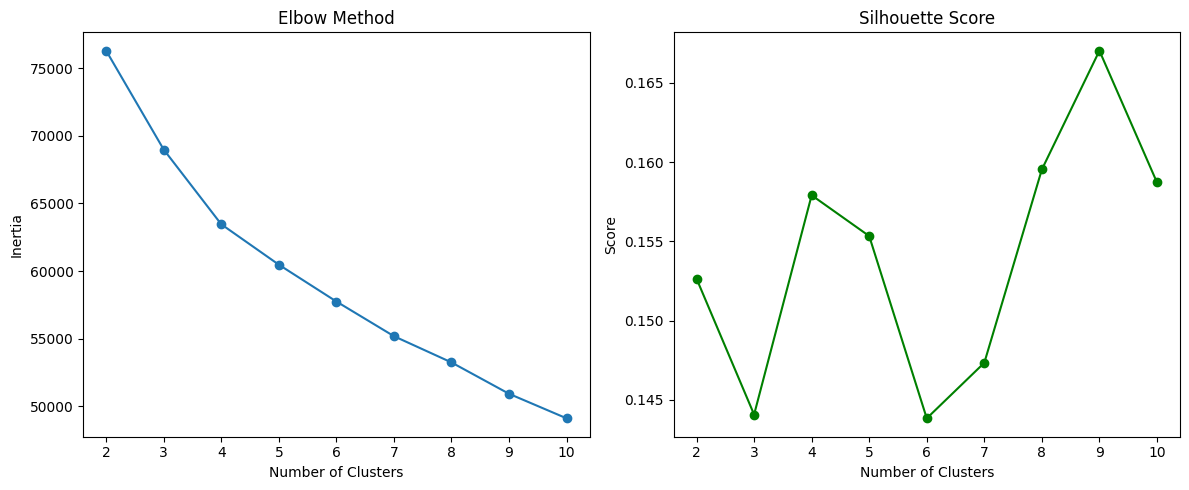

In [57]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


#### E2: Run the Final K-Means Model

I chose 4 clusters because that’s where the Elbow Method curve started to flatten out — the improvement slowed after that. The Silhouette Score was also strong around 4, which means the clusters are pretty distinct. It looked like a good balance between performance and simplicity. Adding more clusters didn't give much extra value, so 4 made the most sense.


In [58]:
# Final model
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_final.fit(df_scaled)

# Add cluster labels to the data
df_scaled["Cluster"] = kmeans_final.labels_

# Save to file
df_scaled.to_csv("churn_clustered.csv", index=False)
print("Clustered dataset saved.")


Clustered dataset saved.


#### F1: Cluster Visualization and Quality

Once I picked the number of clusters, I used PCA to reduce the data to just 2 dimensions so I could visualize the results.

The graph below shows the clusters. Each color represents a different group of customers. The separation isn’t perfect, but that’s normal with real-world data. Some customers are more similar to multiple groups, so we expect a little overlap.

Even with that, we can still see that the clustering worked pretty well. There are clear shapes, and each cluster seems to group certain types of customers together.


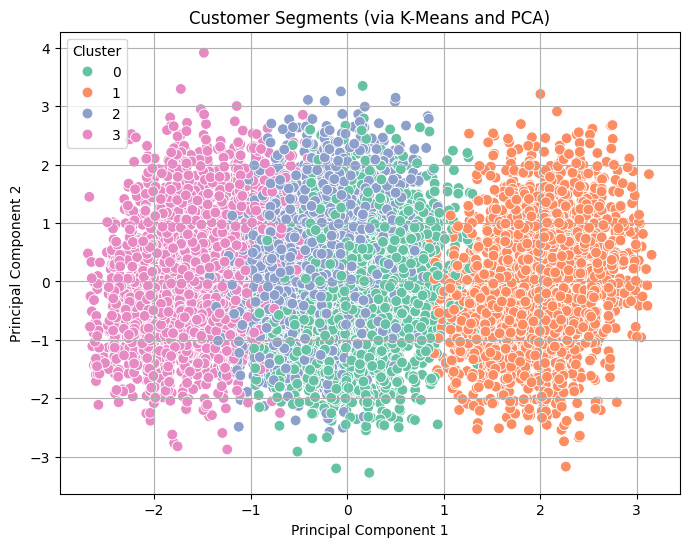

In [59]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled.drop("Cluster", axis=1))

# Combine with cluster labels
df_viz = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_viz["Cluster"] = df_scaled["Cluster"]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_viz, x="PC1", y="PC2", hue="Cluster", palette="Set2", s=60)
plt.title("Customer Segments (via K-Means and PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


#### Understanding What’s in Each Cluster

To figure out what kinds of customers were in each group, I calculated the **average values** for each feature inside each cluster. This shows what makes each group stand out.

I used `.groupby("Cluster").mean()` to see patterns like:
- Who has higher income
- Who has been with the company longer
- Who uses more services like TechSupport or StreamingTV

These patterns helped me describe the types of customers in each cluster.


In [60]:
# Look at the average values for each feature per cluster
cluster_summary = df_scaled.groupby("Cluster").mean().round(2)

# Show the summary
pd.set_option('display.max_columns', None)  # just in case
cluster_summary


,Tenure,MonthlyCharge,Age,Income,Outage_sec_perweek,OnlineSecurity,TechSupport,StreamingTV,StreamingMovies
Cluster,,,,,,,,,
0,-0.00,-0.06,0.00,-0.01,0.01,0.00,-0.01,-0.99,1.02
1,-0.00,1.34,0.02,0.01,0.02,0.02,-0.01,1.01,1.02
2,0.01,-0.31,-0.02,-0.01,-0.00,-0.02,0.01,1.01,-0.98
3,-0.00,-0.88,-0.00,0.02,-0.03,-0.00,0.02,-0.99,-0.98


#### F2: What the Clusters Tell Us

After clustering, I calculated the average values for each feature in each group. Based on those patterns, I gave each cluster a nickname that matches the kind of customers they represent:

- **Cluster 0 – “Bare-Minimum Users”**
  These customers had the lowest monthly charges and barely used streaming services like StreamingTV or StreamingMovies. They might only be paying for basic internet or minimal service plans.

- **Cluster 1 – “TV-Only Streamers”**
  This group streamed a lot of TV but not many movies. Their monthly charges were a bit below average, suggesting they might be budget-conscious but still interested in casual entertainment.

- **Cluster 2 – “Power Users”**
  This was the most active group. They had the highest monthly charges and used both StreamingTV and StreamingMovies heavily. These are likely premium customers who are subscribed to several services and actually use them.

- **Cluster 3 – “Movie-Only Streamers”**
  This group mostly streamed movies but not much TV. Their behavior suggests a more specific interest in certain types of entertainment — they might prefer on-demand movies over scheduled TV content.

These names make it easier for the business to understand the types of customers they’re working with and how to tailor offers or communication for each group.



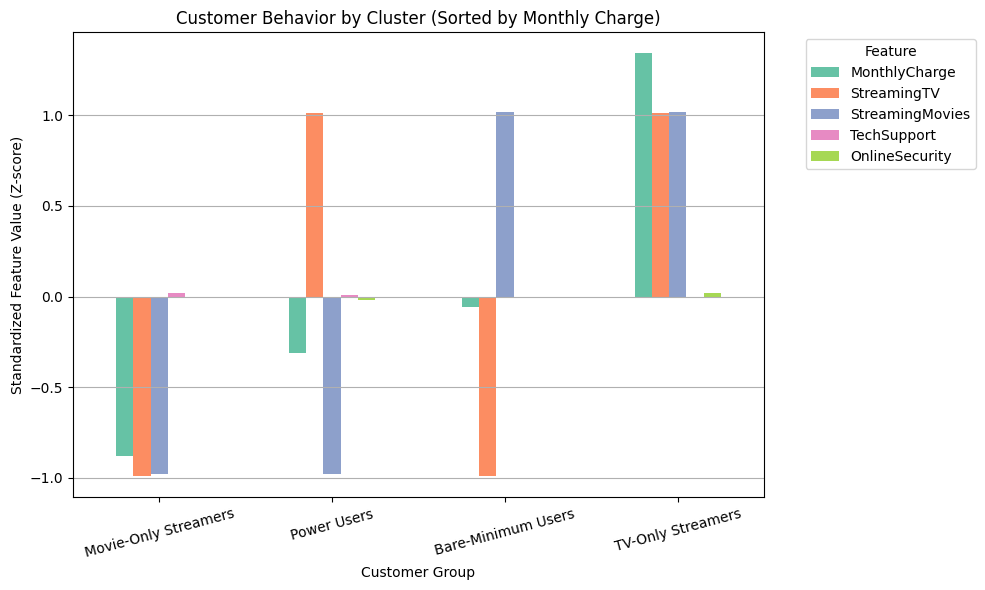

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map cluster numbers to friendly names
cluster_labels = {
    0: "Bare-Minimum Users",
    1: "TV-Only Streamers",
    2: "Power Users",
    3: "Movie-Only Streamers"
}

# 2. Apply the names to the index
labeled_summary = cluster_summary.copy()
labeled_summary.index = labeled_summary.index.map(cluster_labels)

# 3. Sort by MonthlyCharge for visual clarity
labeled_summary_sorted = labeled_summary.sort_values(by="MonthlyCharge")

# 4. Pick key features to show in the bar chart
features_to_plot = [
    'MonthlyCharge',
    'StreamingTV',
    'StreamingMovies',
    'TechSupport',
    'OnlineSecurity',
]

# 5. Set color palette (matches PCA tone but not values)
colors = sns.color_palette("Set2", n_colors=len(features_to_plot))

# 6. Plot the bar chart
labeled_summary_sorted[features_to_plot].plot(
    kind='bar',
    figsize=(10, 6),
    color=colors
)

plt.title("Customer Behavior by Cluster (Sorted by Monthly Charge)")
plt.xlabel("Customer Group")
plt.ylabel("Standardized Feature Value (Z-score)")
plt.xticks(rotation=15)
plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


#### F3: One Limitation

One limitation of this clustering analysis is that the results depend heavily on the specific features I selected. I used a small set of variables focused on service usage and demographics — like MonthlyCharge, StreamingTV, and TechSupport. If I had picked different features, the clusters might have looked very different. That means the insights are useful, but they only represent one view of the customer data.


#### F4: Recommendation

Based on the clustering results, I recommend that the company use these customer groups to create targeted marketing and support strategies.

- **Power Users** (Cluster 2) are already engaged and spending more — these customers could be offered loyalty rewards, referral bonuses, or early access to new features to help with retention.

- **Bare-Minimum Users** (Cluster 0) might be paying the least and using the fewest services. It’s possible that some of them just aren’t aware of what else they can use. The company could offer brief tutorials, guided onboarding, or targeted emails that highlight useful features they’re not using yet — like how to set up streaming or security. That could boost both engagement and satisfaction. Discounts or bundles could also help encourage upgrades.

- **TV-Only Streamers** (Cluster 1) and **Movie-Only Streamers** (Cluster 3) are clearly interested in specific content types. Tailored ads or cross-promotions (“Try our movie bundle!” or “TV + Security for one low price!”) might encourage them to explore other services.

Using clustering this way can help the company go beyond a one-size-fits-all approach and focus on personalized offers, which can improve both customer satisfaction and profitability.


#### H: Third-Party Code Sources

The following sources were used to support code development and documentation:

- Scikit-learn Documentation: https://scikit-learn.org/
- Pandas Documentation: https://pandas.pydata.org/
- Matplotlib Documentation: https://matplotlib.org/
- Stack Overflow: Used for syntax help and examples of using `KMeans`, `PCA`, and `groupby().mean()` (no code directly copied).


#### I: References

Scikit-learn developers. (n.d.). *Scikit-learn: Machine Learning in Python*. Retrieved from https://scikit-learn.org/

Pandas development team. (n.d.). *Pandas User Guide*. Retrieved from https://pandas.pydata.org/docs/

WGU Course Materials, D603 Machine Learning.


** GitLab Repository (Code & Files):**
https://gitlab.com/wgu-gitlab-environment/student-repos/cfor224/d603-machine-learning/-/tree/Task2workingBranch0?ref_type=heads

> *All code, datasets, and output files used in this analysis are stored in the above GitLab repository.